# 02d — Diagnostic anomalies (session 14/05/2026)

Analyse fine des essais douteux repérés au sanity check (02c) de la session du 14/05.

**Pour chaque essai, on regarde** :
1. **Z brut** du barycentre Dos (avant preprocess)
2. **Les 4 marqueurs Dos** séparés sur Z (qui est en cause ?)
3. **signal_final** preprocessed (.npz produit)
4. **Décomposition EMD** complète + IMFs sélectionnées
5. **Spectre Welch** [0-5 Hz]

**Essais douteux à diagnostiquer (3)** :
- `008RiMo / silence` — spike isolé visible sur sanity_check_signals (axe ±100 mm)
- `008RiMo / tempo_random` — signal globalement écrasé + 2-3 spikes énormes vers 50-80s
- `011RiJo / beatmove_adaptatif` — spike vers 200s (axe ±100 mm)

**Objectif** : décider pour chaque essai :
- (a) **outliers ponctuels** → crop_end ajusté ou interpolation locale → GARDER
- (b) **contamination large** → EXCLUDE

In [1]:
from resilience import paths, participants, config
from resilience.io import loader, writer
from resilience.processing import preprocess
from resilience.processing.preprocess import (
    interpolate_nans, compute_barycenter,
    apply_emd_decomposition, imf_dominant_frequency
)
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
%matplotlib inline

# Tentative d'import direct PyEMD pour avoir les IMFs brutes
try:
    from PyEMD import EMD
    _EMD = EMD()
    EMD_OK = True
except ImportError:
    EMD_OK = False
    print('⚠️  PyEMD pas dispo')

In [2]:
ANOMALIES = [
    ('008RiMo', 'silence'),
    ('008RiMo', 'tempo_random'),
    ('011RiJo', 'beatmove_adaptatif'),
]

## Fonction de diagnostic complète pour 1 essai

In [3]:
def diagnose(participant, condition):
    print(f"\n{'═'*70}\n  DIAGNOSTIC : {participant} / {condition}\n{'═'*70}")

    # 1. Charger .mat brut (et appliquer crops si présents, comme le batch)
    raw_path = paths.raw_file(participant, condition)
    data, fmt = loader.load_mat(raw_path)
    trajectories = loader.extract_marker_trajectories(data, fmt)

    trial = participants.get_trial(participant, condition)
    n_before = next(iter(trajectories.values())).shape[0]
    i_start = int(trial.crop_start_s * config.FS_RAW) if trial.crop_start_s else 0
    i_end   = int(trial.crop_end_s * config.FS_RAW) if trial.crop_end_s else n_before
    trajectories = {m: xyz[i_start:i_end] for m, xyz in trajectories.items()}

    print(f"  Crops : start={trial.crop_start_s}, end={trial.crop_end_s}")
    print(f"  Frames après crop : {i_end-i_start} ({(i_end-i_start)/config.FS_RAW:.0f}s)")

    # 2. Z brut sacrum + marqueurs Dos séparés
    bary = compute_barycenter(trajectories, center_on_mean=True)
    sacrum_z_raw = bary[:, 2]
    t_raw = np.arange(len(sacrum_z_raw)) / config.FS_RAW

    dos_z = {}
    for m in ('Dos01', 'Dos02', 'Dos03', 'Dos04'):
        z = trajectories[m][:, 2].copy()
        # Sans interpolation pour voir les NaN bruts
        dos_z[m] = z

    # Stats par marqueur
    print(f"\n  Visibilité par marqueur (% non-NaN) :")
    for m, z in dos_z.items():
        valid = np.sum(~np.isnan(z)) / len(z) * 100
        amp = float(np.nanpercentile(z, 95) - np.nanpercentile(z, 5)) if valid > 5 else np.nan
        print(f"    {m} : {valid:.1f}%  | amplitude pic-à-pic = {amp:.1f} mm")

    # Stats sacrum brut (détection spikes)
    sac_med = np.nanmedian(sacrum_z_raw)
    sac_mad = np.nanmedian(np.abs(sacrum_z_raw - sac_med))
    threshold = sac_med + 8 * sac_mad  # seuil généreux pour outlier
    n_spikes_pos = int(np.sum(sacrum_z_raw > threshold))
    n_spikes_neg = int(np.sum(sacrum_z_raw < (sac_med - 8 * sac_mad)))
    print(f"\n  Sacrum brut : médiane={sac_med:.1f} mm, MAD={sac_mad:.1f} mm")
    print(f"    Spikes |z|>8·MAD : +{n_spikes_pos} / -{n_spikes_neg} samples")
    if n_spikes_pos + n_spikes_neg > 0:
        idx_spikes = np.where(np.abs(sacrum_z_raw - sac_med) > 8 * sac_mad)[0]
        t_spikes = idx_spikes / config.FS_RAW
        print(f"    Localisation temporelle : {t_spikes.min():.1f}s → {t_spikes.max():.1f}s")

    # 3. Charger le .npz produit
    payload = writer.load_processed(participant, condition)
    sig_final = payload['signal_final']
    t_final   = payload['time_final']

    # 4. Refaire EMD pour avoir les IMFs et la sélection
    if EMD_OK:
        IMFs = _EMD(sacrum_z_raw)
        freqs = [imf_dominant_frequency(imf, config.FS_RAW) for imf in IMFs]
        f_low, f_high = config.WALKING_BAND_HZ
        selected = [i for i, f in enumerate(freqs) if f_low <= f <= f_high]
        print(f"\n  EMD : {len(IMFs)} IMFs")
        for i, f in enumerate(freqs):
            tag = '✓' if i in selected else ' '
            print(f"    [{tag}] IMF{i:2d} : f_dom = {f:.3f} Hz")
        print(f"  Bande [{f_low}-{f_high} Hz] → sélectionnées : {selected}")
    else:
        IMFs = None
        selected = []

    # ══════════════════════════════════════════════════════════════
    # PLOTS
    # ══════════════════════════════════════════════════════════════
    fig = plt.figure(figsize=(14, 16))
    gs = fig.add_gridspec(6, 1, hspace=0.45)

    # Plot A : sacrum Z brut
    ax = fig.add_subplot(gs[0])
    ax.plot(t_raw, sacrum_z_raw, color='steelblue', linewidth=0.4)
    ax.axhline(sac_med + 8*sac_mad, color='red', linewidth=0.5, linestyle='--', alpha=0.5, label='±8·MAD')
    ax.axhline(sac_med - 8*sac_mad, color='red', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.set_title('A. Sacrum Z brut (barycentre Dos01-04, après crops, centré)', loc='left', fontsize=10)
    ax.set_ylabel('Z (mm)')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

    # Plot B : 4 marqueurs Dos séparés sur Z
    ax = fig.add_subplot(gs[1])
    for m, z in dos_z.items():
        # Centrer pour comparaison visuelle
        z_centered = z - np.nanmean(z)
        ax.plot(t_raw, z_centered, linewidth=0.4, label=m, alpha=0.7)
    ax.set_title('B. 4 marqueurs Dos séparés (Z centrés) — identifier le marqueur fautif', loc='left', fontsize=10)
    ax.set_ylabel('Z centré (mm)')
    ax.legend(loc='upper right', fontsize=7, ncol=4)
    ax.grid(alpha=0.3)

    # Plot C : signal_final (preprocessed)
    ax = fig.add_subplot(gs[2])
    ax.plot(t_final, sig_final, color='darkorange', linewidth=0.5)
    ax.set_title('C. signal_final (Z preprocessed, 100 Hz)', loc='left', fontsize=10)
    ax.set_ylabel('Z (mm)')
    ax.grid(alpha=0.3)

    # Plot D : IMFs sélectionnées (somme = ce qui devient sig_final)
    ax = fig.add_subplot(gs[3])
    if IMFs is not None and selected:
        for i in selected:
            ax.plot(t_raw, IMFs[i], linewidth=0.5, alpha=0.7,
                    label=f'IMF{i} ({freqs[i]:.2f}Hz)')
        ax.set_title(f'D. IMFs sélectionnées (somme = signal reconstruit pré-filtrage)',
                     loc='left', fontsize=10)
        ax.legend(fontsize=7, loc='upper right', ncol=min(len(selected), 4))
    else:
        ax.text(0.5, 0.5, 'Pas d\'IMFs disponibles', ha='center', transform=ax.transAxes)
    ax.set_ylabel('Amplitude')
    ax.grid(alpha=0.3)

    # Plot E : IMFs NON sélectionnées (avec leur f_dom)
    ax = fig.add_subplot(gs[4])
    if IMFs is not None:
        non_selected = [i for i in range(len(IMFs)) if i not in selected]
        for i in non_selected[:8]:  # max 8 pour lisibilité
            ax.plot(t_raw, IMFs[i], linewidth=0.4, alpha=0.6,
                    label=f'IMF{i} ({freqs[i]:.2f}Hz)')
        ax.set_title('E. IMFs NON sélectionnées (informatif)', loc='left', fontsize=10)
        ax.legend(fontsize=7, loc='upper right', ncol=4)
    ax.set_ylabel('Amplitude')
    ax.grid(alpha=0.3)

    # Plot F : Spectre Welch du signal_final
    ax = fig.add_subplot(gs[5])
    f, pxx = welch(sig_final, fs=config.FS_CLEAN,
                    nperseg=min(len(sig_final), 4*config.FS_CLEAN))
    ax.semilogy(f, pxx, color='darkorange', linewidth=0.8)
    ax.axvspan(*config.WALKING_BAND_HZ, color='green', alpha=0.1, label='Bande marche')
    mask = (f >= config.WALKING_BAND_HZ[0]) & (f <= config.WALKING_BAND_HZ[1])
    if mask.any():
        f_dom = f[mask][np.argmax(pxx[mask])]
        ax.axvline(f_dom, color='red', linewidth=1, label=f'f_dom = {f_dom:.2f} Hz')
    ax.set_xlim(0, 5)
    ax.set_xlabel('Fréquence (Hz)')
    ax.set_ylabel('PSD')
    ax.set_title('F. Spectre Welch du signal_final', loc='left', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    plt.suptitle(f'Diagnostic : {participant} / {condition}',
                  fontsize=12, fontweight='bold', y=1.0)
    plt.savefig(f'diag_{participant}_{condition}.png', dpi=80, bbox_inches='tight')
    plt.show()

## Diagnostic 1/3 — 008RiMo / silence

**Symptôme** : axe Y ±100 mm avec un gros spike isolé. Amplitude affichée 39.1 mm.
**À vérifier** : 1 outlier ponctuel (crop ?) ou contamination plus large ?


══════════════════════════════════════════════════════════════════════
  DIAGNOSTIC : 008RiMo / silence
══════════════════════════════════════════════════════════════════════
  Crops : start=60.0, end=None
  Frames après crop : 168001 (420s)

  Visibilité par marqueur (% non-NaN) :
    Dos01 : 90.4%  | amplitude pic-à-pic = 97.3 mm
    Dos02 : 91.1%  | amplitude pic-à-pic = 98.1 mm
    Dos03 : 91.3%  | amplitude pic-à-pic = 96.6 mm
    Dos04 : 91.4%  | amplitude pic-à-pic = 96.1 mm

  Sacrum brut : médiane=0.6 mm, MAD=26.2 mm
    Spikes |z|>8·MAD : +88 / -0 samples
    Localisation temporelle : 166.7s → 258.2s

  EMD : 19 IMFs
    [ ] IMF 0 : f_dom = 4.500 Hz
    [ ] IMF 1 : f_dom = 15.500 Hz
    [ ] IMF 2 : f_dom = 4.250 Hz
    [ ] IMF 3 : f_dom = 4.750 Hz
    [ ] IMF 4 : f_dom = 5.250 Hz
    [✓] IMF 5 : f_dom = 1.750 Hz
    [✓] IMF 6 : f_dom = 1.750 Hz
    [✓] IMF 7 : f_dom = 1.750 Hz
    [✓] IMF 8 : f_dom = 1.750 Hz
    [✓] IMF 9 : f_dom = 1.000 Hz
    [✓] IMF10 : f_dom = 0.500 Hz


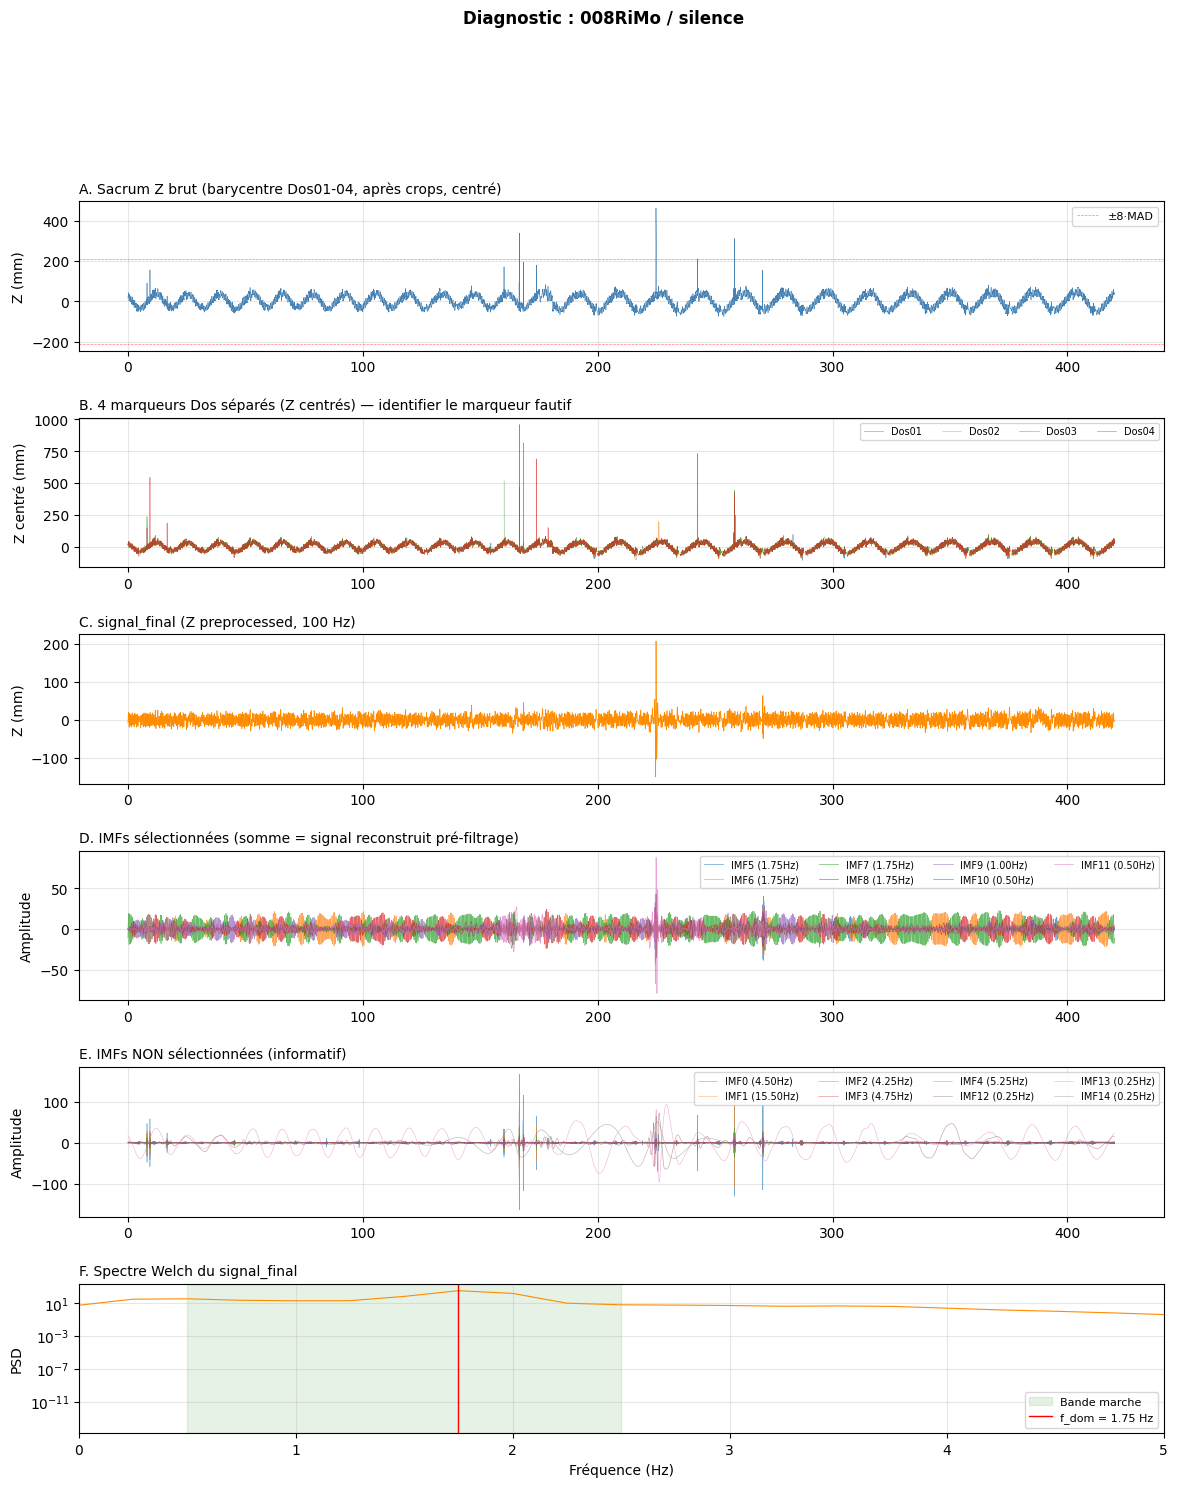

In [4]:
diagnose('008RiMo', 'silence')

## Diagnostic 2/3 — 008RiMo / tempo_random

**Symptôme** : signal globalement plat avec 2-3 spikes énormes (~±200 mm) vers 50-80s.
**À vérifier** : amplitude 45 mm tirée uniquement par les spikes ? Marqueurs Dos cassés comme P007 ?


══════════════════════════════════════════════════════════════════════
  DIAGNOSTIC : 008RiMo / tempo_random
══════════════════════════════════════════════════════════════════════
  Crops : start=60.0, end=None
  Frames après crop : 168001 (420s)

  Visibilité par marqueur (% non-NaN) :
    Dos01 : 94.6%  | amplitude pic-à-pic = 99.0 mm
    Dos02 : 95.0%  | amplitude pic-à-pic = 99.1 mm
    Dos03 : 95.2%  | amplitude pic-à-pic = 99.7 mm
    Dos04 : 95.1%  | amplitude pic-à-pic = 98.7 mm

  Sacrum brut : médiane=0.4 mm, MAD=24.5 mm
    Spikes |z|>8·MAD : +230 / -0 samples
    Localisation temporelle : 1.0s → 386.5s

  EMD : 21 IMFs
    [✓] IMF 0 : f_dom = 2.500 Hz
    [ ] IMF 1 : f_dom = 2.750 Hz
    [ ] IMF 2 : f_dom = 2.750 Hz
    [ ] IMF 3 : f_dom = 3.500 Hz
    [ ] IMF 4 : f_dom = 3.250 Hz
    [✓] IMF 5 : f_dom = 1.750 Hz
    [✓] IMF 6 : f_dom = 1.750 Hz
    [✓] IMF 7 : f_dom = 1.750 Hz
    [✓] IMF 8 : f_dom = 1.750 Hz
    [✓] IMF 9 : f_dom = 1.250 Hz
    [✓] IMF10 : f_dom = 0.750 

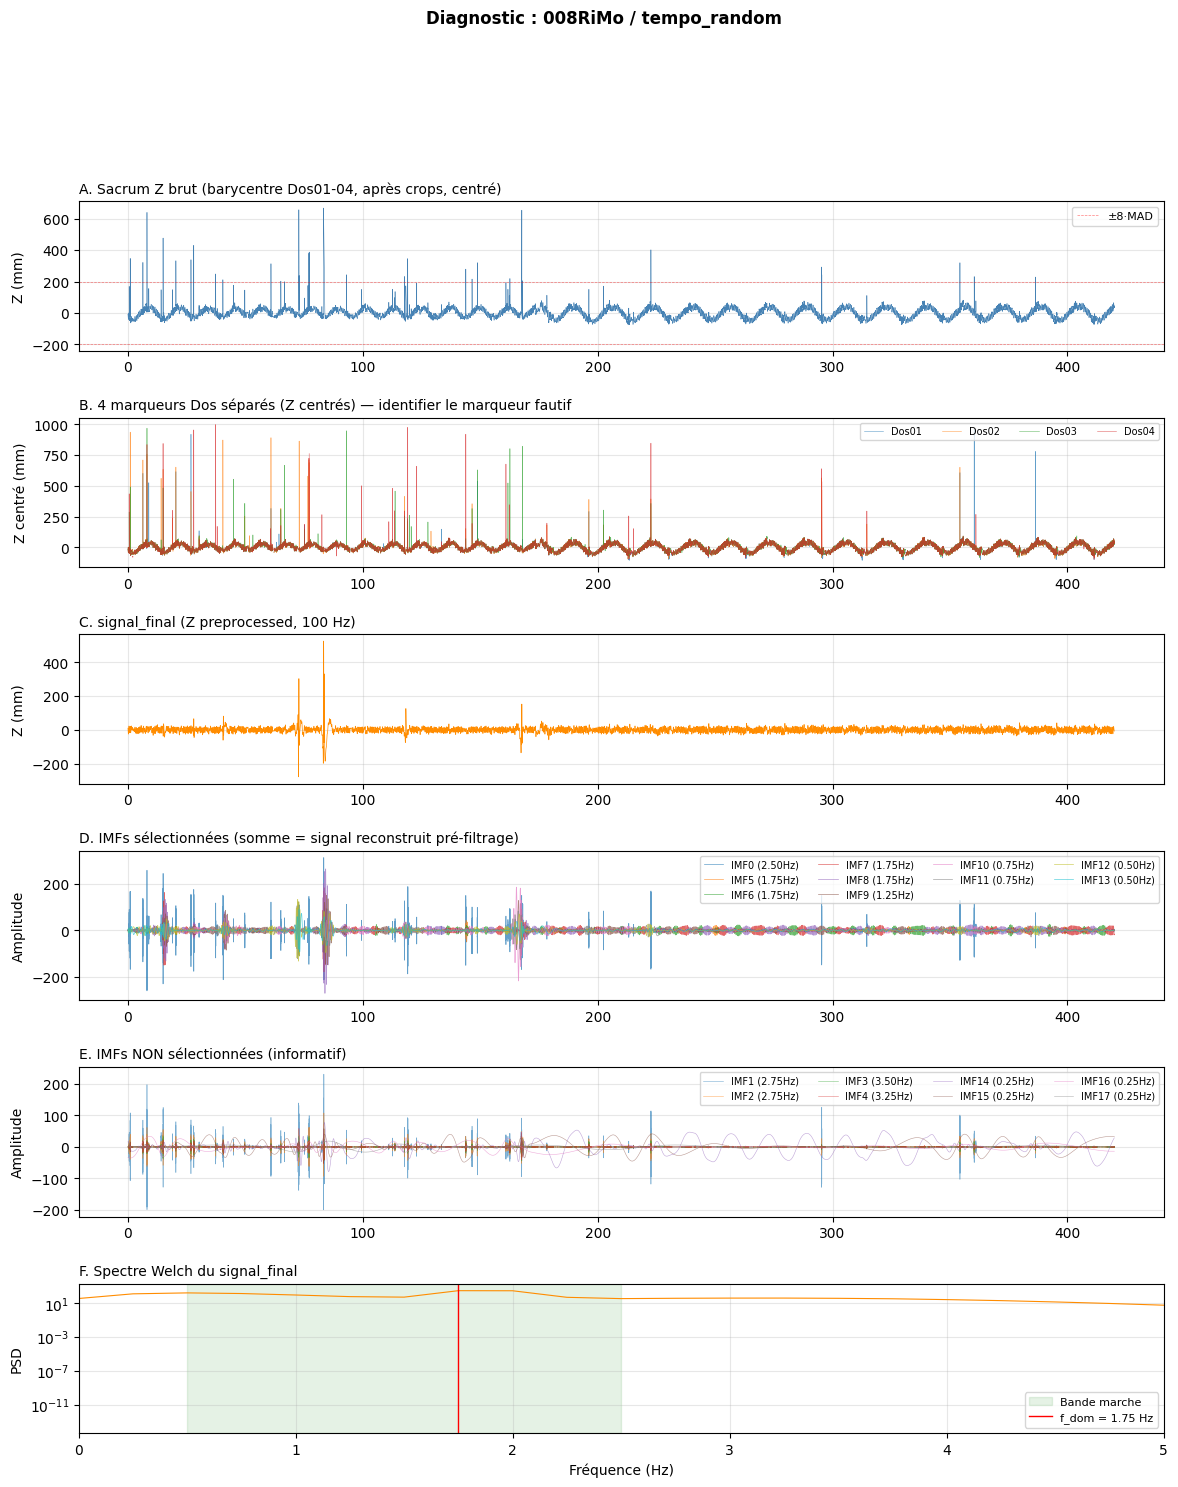

In [5]:
diagnose('008RiMo', 'tempo_random')

## Diagnostic 3/3 — 011RiJo / beatmove_adaptatif

**Symptôme** : axe Y ±100 mm, un spike vers 200s. amp=38.2 mm.
**À vérifier** : avant/après CRF (perturbation ≈ 200s ?) → si dans la zone CRF, dramatique.


══════════════════════════════════════════════════════════════════════
  DIAGNOSTIC : 011RiJo / beatmove_adaptatif
══════════════════════════════════════════════════════════════════════
  Crops : start=60.0, end=None
  Frames après crop : 168000 (420s)

  Visibilité par marqueur (% non-NaN) :
    Dos01 : 95.0%  | amplitude pic-à-pic = 64.1 mm
    Dos02 : 95.6%  | amplitude pic-à-pic = 65.5 mm
    Dos03 : 96.3%  | amplitude pic-à-pic = 61.3 mm
    Dos04 : 95.5%  | amplitude pic-à-pic = 61.0 mm

  Sacrum brut : médiane=0.5 mm, MAD=12.9 mm
    Spikes |z|>8·MAD : +20 / -0 samples
    Localisation temporelle : 12.2s → 387.5s

  EMD : 20 IMFs
    [ ] IMF 0 : f_dom = 5.000 Hz
    [ ] IMF 1 : f_dom = 15.750 Hz
    [ ] IMF 2 : f_dom = 29.250 Hz
    [ ] IMF 3 : f_dom = 6.500 Hz
    [ ] IMF 4 : f_dom = 5.500 Hz
    [✓] IMF 5 : f_dom = 1.750 Hz
    [✓] IMF 6 : f_dom = 1.750 Hz
    [✓] IMF 7 : f_dom = 1.500 Hz
    [✓] IMF 8 : f_dom = 1.500 Hz
    [✓] IMF 9 : f_dom = 1.500 Hz
    [✓] IMF10 : f_dom 

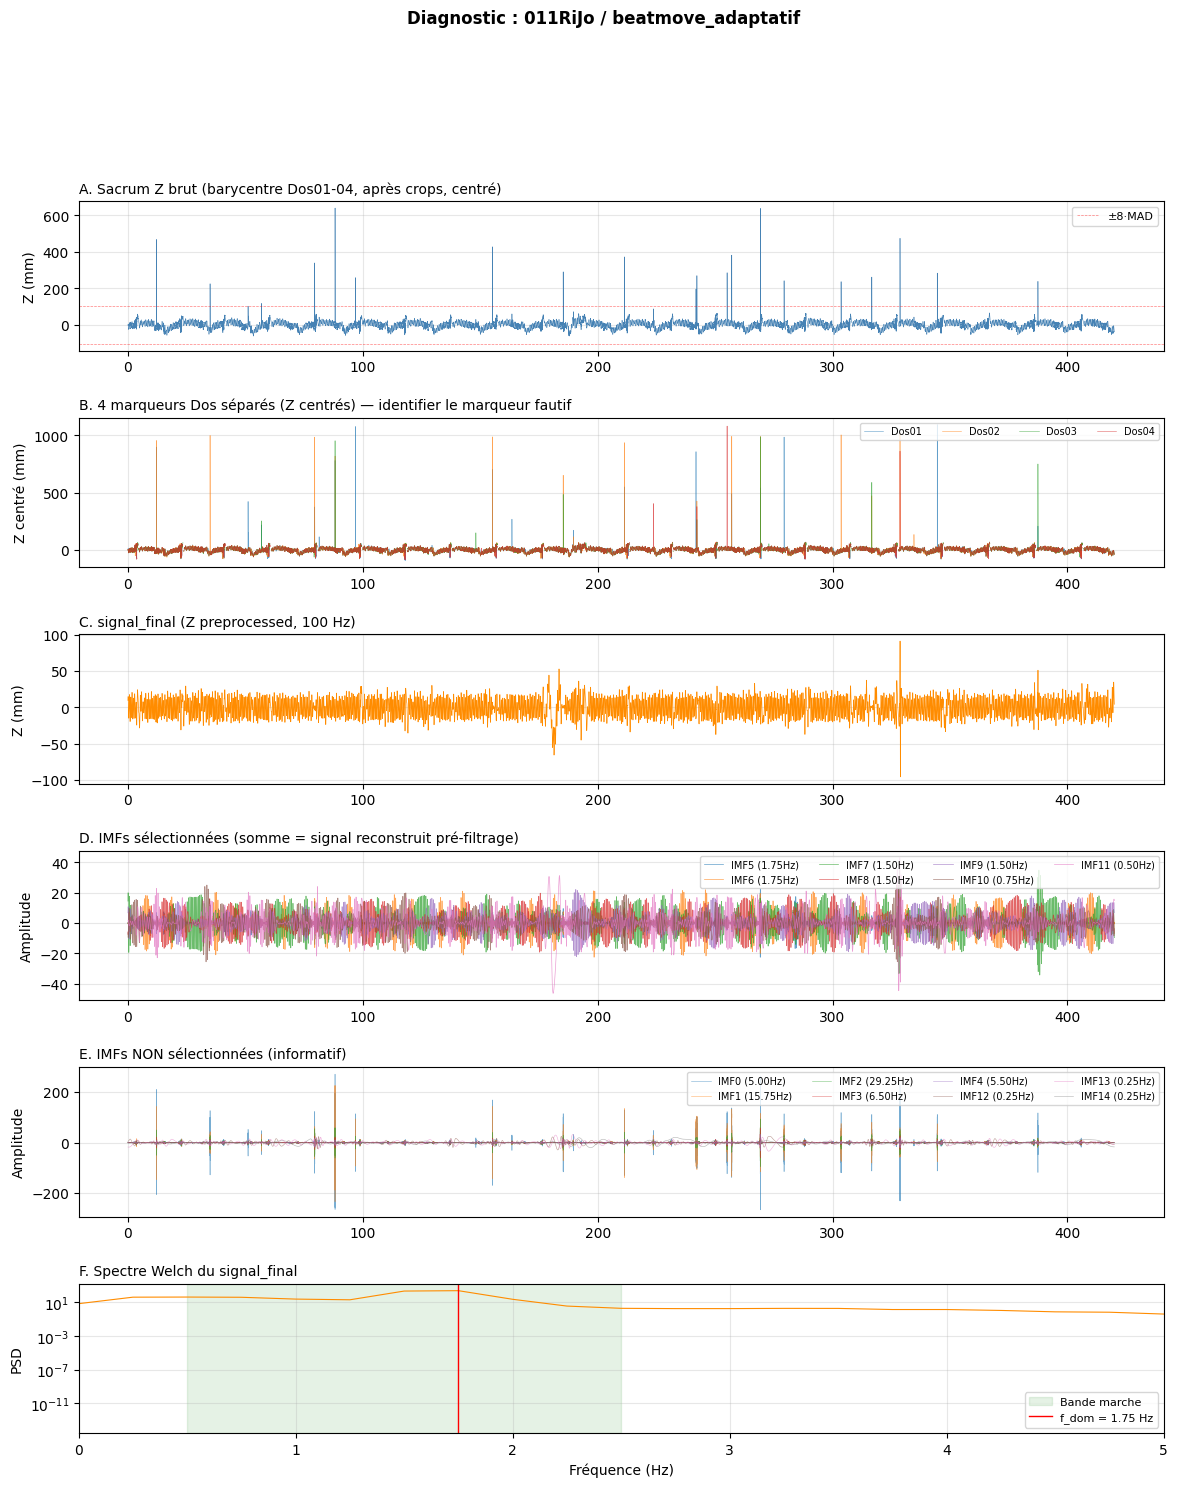

In [6]:
diagnose('011RiJo', 'beatmove_adaptatif')

## Décisions à reporter dans `participants.py`

Après inspection des 3 diagnostics ci-dessus, formaliser ici les actions :

| Essai | Spike loc (s) | Cause probable | Action |
|---|---|---|---|
| 008RiMo / silence | ... | ... | ... |
| 008RiMo / tempo_random | ... | ... | ... |
| 011RiJo / beatmove_adaptatif | ... | ... | ... |

**Actions possibles** :
- `crop_end_s` raccourci si spike dans les dernières secondes
- `crop_start_s` augmenté si spike dans les premières secondes
- Ajout à `EXCLUDED_TRIALS` si contamination centrale (proche CRF) ou marqueur cassé
- Interpolation locale (à coder dans `preprocess`) si spike isolé < 5 frames

Après décision : modifier `participants.py`, relancer **uniquement les essais affectés** dans le notebook 02 (pas tout le batch).